In [1]:
# Copyright (c) TorchGeo Contributors. All rights reserved.
# Licensed under the MIT License.

# Spatiotemporal Segmentation with ConvLSTM
_Written by: Yi-Chia Chang_

In this tutorial, we demonstrate how to train a model for 3D semantic segmentation task using TorchGeo.

In this tutorial, we will train a [ConvLSTM](https://docs.torchgeo.org/en/stable/api/models/convlstm.html) semantic segmentation model using the [PASTIS100](https://torchgeo.readthedocs.io/en/stable/api/datasets/pastis.html) dataset to detect crop types in France using time-series Sentinel-2 imagery. By ingesting time-series Sentinel-2 imagery and crop-type labels, our model can predict pixel-level crop type.

It is recommended to use a GPU to accelerate the training and inference process. The demo is tested on Google Colab.

## Setup

In [ ]:
%pip install torchgeo

## Imports

In [59]:
%matplotlib inline

import os
import tempfile

import kornia.augmentation as K

import lightning as L
import matplotlib.pyplot as plt
import torch
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import TensorBoardLogger

from torchgeo.datamodules import PASTIS100DataModule
from torchgeo.datasets import PASTIS100
from torchgeo.trainers import SpatioTemporalSegmentationTask

torch.set_float32_matmul_precision('medium')
L.seed_everything(0, workers=True)

INFO: Seed set to 0
INFO:lightning.fabric.utilities.seed:Seed set to 0


0

## Visualize the dataset

About PASTIS100: This dataset downsampled 100 patches of the original [PASTIS](https://docs.torchgeo.org/en/stable/api/datasets/pastis.html) dataset. PASTIS100 contains 100 patches of 128×128 with a variable-length Sentinel-2 time-series per patch and a static 20-class semantic mask. We use all 10 L2A bands as training inputs. We split the dataset into 60 training, 20 validation, and 20 test samples.

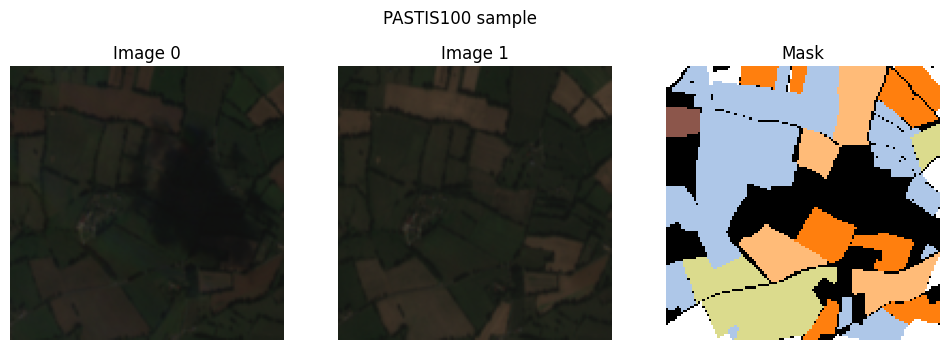

100 patches, (43, 10, 128, 128) (T, C, H, W)


In [4]:
root = os.path.join(tempfile.gettempdir(), 'pastis100')
dataset = PASTIS100(root=root, bands=PASTIS100.s2_bands, download=True)
import random

fig = dataset.plot(dataset[91], suptitle='PASTIS100 sample')

plt.show()
print(f'{len(dataset)} patches, {tuple(dataset[0]["image"].shape)} (T, C, H, W)')

## Datamodule

We will utilize TorchGeo's [Lightning](https://lightning.ai/docs/pytorch/stable/) datamodules to organize the dataloader setup.

In [68]:
datamodule = PASTIS100DataModule(
    root=root, bands=PASTIS100.s2_bands, batch_size=4, num_workers=4, padding_length=30,
)

## Spatio-temporal Segmentation Task

`SpatioTemporalSegmentationTask` is a trainer designed for time-series imagery with static segmentation labels.

In [69]:
task = SpatioTemporalSegmentationTask(
    model='convlstm',
    in_channels=10,
    num_classes=20,
    ignore_index=19,
    loss='dice',
    hidden_dim=64,
    num_layers=2,
    kernel_size=3,
)

## Training a deep learning model from scratch

We can use Lightning's `Trainer` and TorchGeo's `SpatioTemporalSegmentationTask` to simplify the training.

In [70]:
trainer = Trainer(
    max_epochs=15,
    accelerator='auto',
    callbacks=[
        EarlyStopping('val_loss', patience=15),
        ModelCheckpoint(monitor='val_loss', mode='min'),
    ],
)
trainer.fit(task, datamodule=datamodule)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ ConvLSTM         │  467 K │ train │     0 │
│ 1 │ criterion     │ DiceLoss         │      0 │ train │     0 │
│ 2 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 3 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 467 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 467 K                                                                                                
Total estimated model params size (MB): 1.869                                                                      
Modules in train mode: 71                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/fit_loop.py:321: The number of training batches 
(15) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if
you want to see logs for the training epoch.

INFO: `Trainer.fit` stopped: `max_epochs=15` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=15` reached.


## Test the model
We can load the best checkpoint to test the model on the test split of the dataset.

In [71]:
trainer.test(model=task, datamodule=datamodule, ckpt_path='best')

INFO: Restoring states from the checkpoint path at /content/lightning_logs/version_12/checkpoints/epoch=13-step=210.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /content/lightning_logs/version_12/checkpoints/epoch=13-step=210.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /content/lightning_logs/version_12/checkpoints/epoch=13-step=210.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /content/lightning_logs/version_12/checkpoints/epoch=13-step=210.ckpt
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()

/usr/local/lib/python3.12/dist-packages/torchgeo/datasets/utils.py:616: UserWarning: Truncated 4 sequences to length 30.
  warnings.warn(f'Truncated {truncated} sequences to length {padding_length}.')
/usr/local/lib/python3.12/dist-packages/torchgeo/datasets/utils.py:616: UserWarning: Truncated 4 sequences to length 30.
  warnings.warn(f'Truncated {truncated} sequences to length {padding_length}.')
/usr/local/lib/python3.12/dist-packages/torchgeo/datasets/utils.py:616: UserWarning: Truncated 4 sequences to length 30.
  warnings.warn(f'Truncated {truncated} sequences to length {padding_length}.')
/usr/local/lib/python3.12/dist-packages/torchgeo/datasets/utils.py:616: UserWarning: Truncated 4 sequences to length 30.
  warnings.warn(f'Truncated {truncated} sequences to length {padding_length}.')


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃          Test metric          ┃         DataLoader 0          ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     test_AverageAccuracy      │      0.4434086084365845       │
│      test_AverageF1Score      │      0.42263084650039673      │
│   test_AverageJaccardIndex    │      0.33454036712646484      │
│     test_AveragePrecision     │      0.4086105227470398       │
│      test_AverageRecall       │      0.4434086084365845       │
│   test_ClasswiseAccuracy_0    │      0.6779542565345764       │
│   test_ClasswiseAccuracy_1    │      0.7201967835426331       │
│   test_ClasswiseAccuracy_10   │              0.0              │
│   test_ClasswiseAccuracy_11   │              0.0              │
│   test_ClasswiseAccuracy_12   │      0.4064497947692871       │
│   test_ClasswiseAccuracy_13   │      0.5491422414779663       │
│   test_ClasswiseAccuracy_14   │              0.0              │
│   test_ClasswiseAccuracy_15   │              0.0              │
│   test_ClasswiseAccuracy_16   │              0.0              │
│   test_ClasswiseAccuracy_17   │              0.0              │
│   test_ClasswiseAccuracy_18   │              0.0              │
│   test_ClasswiseAccuracy_19   │              0.0              │
│   test_ClasswiseAccuracy_2    │      0.9081590175628662       │
│   test_ClasswiseAccuracy_3    │      0.7999497056007385       │
│   test_ClasswiseAccuracy_4    │      0.7701716423034668       │
│   test_ClasswiseAccuracy_5    │      0.9269475340843201       │
│   test_ClasswiseAccuracy_6    │              0.0              │
│   test_ClasswiseAccuracy_7    │              0.0              │
│   test_ClasswiseAccuracy_8    │              0.0              │
│   test_ClasswiseAccuracy_9    │       0.892158031463623       │
│    test_ClasswiseF1Score_0    │       0.692541241645813       │
│    test_ClasswiseF1Score_1    │       0.66221022605896        │
│   test_ClasswiseF1Score_10    │              0.0              │
│   test_ClasswiseF1Score_11    │              0.0              │
│   test_ClasswiseF1Score_12    │      0.4615384638309479       │
│   test_ClasswiseF1Score_13    │      0.5711665153503418       │
│   test_ClasswiseF1Score_14    │              0.0              │
│   test_ClasswiseF1Score_15    │              0.0              │
│   test_ClasswiseF1Score_16    │              0.0              │
│   test_ClasswiseF1Score_17    │              0.0              │
│   test_ClasswiseF1Score_18    │              0.0              │
│   test_ClasswiseF1Score_19    │              0.0              │
│    test_ClasswiseF1Score_2    │      0.8551112413406372       │
│    test_ClasswiseF1Score_3    │      0.7552766799926758       │
│    test_ClasswiseF1Score_4    │      0.7352511882781982       │
│    test_ClasswiseF1Score_5    │      0.8869552612304688       │
│    test_ClasswiseF1Score_6    │              0.0              │
│    test_ClasswiseF1Score_7    │              0.0              │
│    test_ClasswiseF1Score_8    │              0.0              │
│    test_ClasswiseF1Score_9    │      0.7194117903709412       │
│ test_ClasswiseJaccardIndex_0  │      0.5296850204467773       │
│ test_ClasswiseJaccardIndex_1  │      0.49500322341918945      │
│ test_ClasswiseJaccardIndex_10 │              0.0              │
│ test_ClasswiseJaccardIndex_11 │              0.0              │
│ test_ClasswiseJaccardIndex_12 │      0.30000001192092896      │
│ test_ClasswiseJaccardIndex_13 │      0.3997432291507721       │
│ test_ClasswiseJaccardIndex_14 │              0.0              │
│ test_ClasswiseJaccardIndex_15 │              0.0              │
│ test_ClasswiseJaccardIndex_16 │              0.0              │
│ test_ClasswiseJaccardIndex_17 │              0.0              │
│ test_ClasswiseJaccardIndex_18 │              0.0              │
│ test_ClasswiseJaccardIndex_19 │              0.0              │
│ test_ClasswiseJaccardIndex_2  │      0

[{'test_loss': 0.38131552934646606,
  'test_ClasswiseAccuracy_0': 0.6779542565345764,
  'test_ClasswiseAccuracy_1': 0.7201967835426331,
  'test_ClasswiseAccuracy_2': 0.9081590175628662,
  'test_ClasswiseAccuracy_3': 0.7999497056007385,
  'test_ClasswiseAccuracy_4': 0.7701716423034668,
  'test_ClasswiseAccuracy_5': 0.9269475340843201,
  'test_ClasswiseAccuracy_6': 0.0,
  'test_ClasswiseAccuracy_7': 0.0,
  'test_ClasswiseAccuracy_8': 0.0,
  'test_ClasswiseAccuracy_9': 0.892158031463623,
  'test_ClasswiseAccuracy_10': 0.0,
  'test_ClasswiseAccuracy_11': 0.0,
  'test_ClasswiseAccuracy_12': 0.4064497947692871,
  'test_ClasswiseAccuracy_13': 0.5491422414779663,
  'test_ClasswiseAccuracy_14': 0.0,
  'test_ClasswiseAccuracy_15': 0.0,
  'test_ClasswiseAccuracy_16': 0.0,
  'test_ClasswiseAccuracy_17': 0.0,
  'test_ClasswiseAccuracy_18': 0.0,
  'test_ClasswiseAccuracy_19': 0.0,
  'test_AverageAccuracy': 0.4434086084365845,
  'test_AverageF1Score': 0.42263084650039673,
  'test_AverageJaccardIndex'

## Visualizing prediction results on test data

/usr/local/lib/python3.12/dist-packages/torchgeo/datasets/utils.py:616: UserWarning: Truncated 4 sequences to length 30.
  warnings.warn(f'Truncated {truncated} sequences to length {padding_length}.')
/usr/local/lib/python3.12/dist-packages/torchgeo/datasets/utils.py:616: UserWarning: Truncated 4 sequences to length 30.
  warnings.warn(f'Truncated {truncated} sequences to length {padding_length}.')
/usr/local/lib/python3.12/dist-packages/torchgeo/datasets/utils.py:616: UserWarning: Truncated 4 sequences to length 30.
  warnings.warn(f'Truncated {truncated} sequences to length {padding_length}.')
/usr/local/lib/python3.12/dist-packages/torchgeo/datasets/utils.py:616: UserWarning: Truncated 4 sequences to length 30.
  warnings.warn(f'Truncated {truncated} sequences to length {padding_length}.')


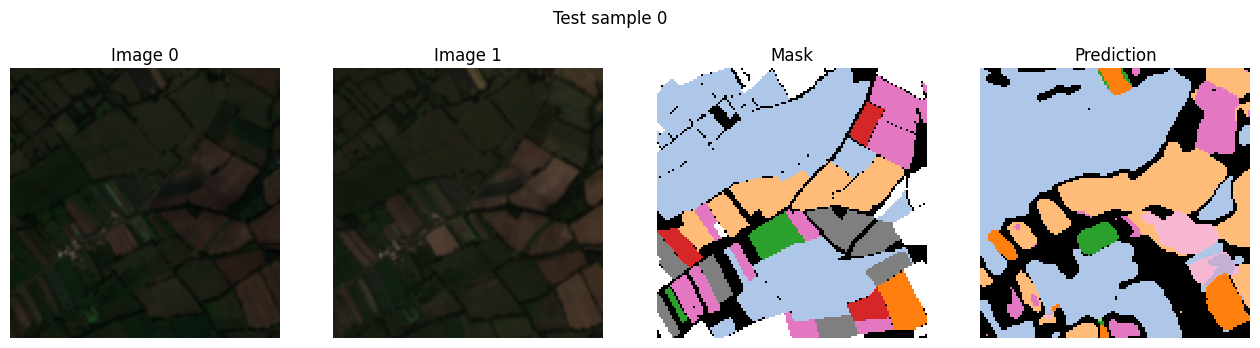

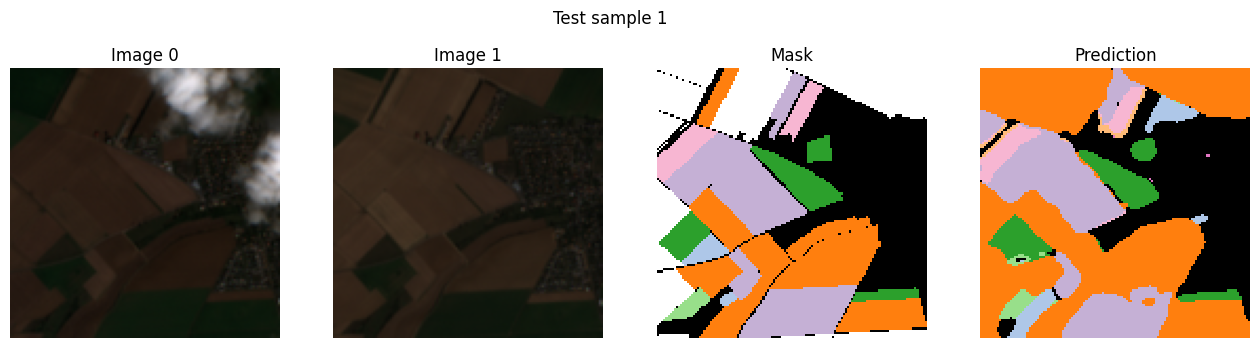

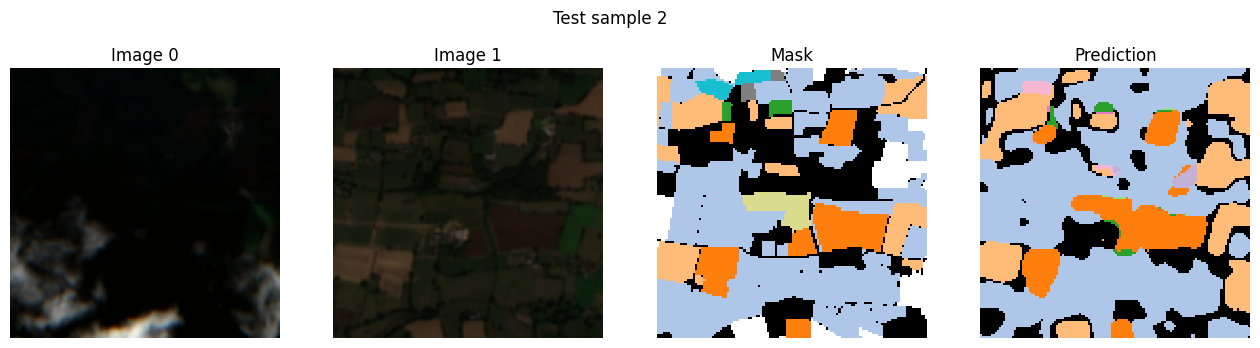

In [72]:
datamodule.setup('test')
dataset = datamodule.test_dataset.dataset

task.eval()

batch = next(iter(datamodule.test_dataloader()))
batch = datamodule.aug(batch)

with torch.no_grad():
    logits = task(batch['image'])
predictions = logits.argmax(dim=1)

for i in range(3):
    sample = {
        'image': batch['image'][i],
        'mask': batch['mask'][i],
        'prediction': predictions[i],
    }
    dataset.plot(sample, suptitle=f'Test sample {i}')
    plt.show()